# Day 18 & 19 — ML Student Performance Prediction and Model Evaluation

## Objective

Build a complete machine-learning workflow using the Student Habits & Academic Performance dataset.

### Workflow
1. EDA and data understanding
2. Data quality and preprocessing
3. Regression: predict `exam_score`
4. Regression evaluation: MAE, MSE, RMSE, R²
5. Classification: predict Pass/Fail using 50 marks as the threshold
6. Classification evaluation: confusion matrix, accuracy, precision, recall, F1-score
7. Training vs testing comparison
8. Overfitting / underfitting discussion
9. Five meaningful student-performance insights

The class notes introduce simple and multiple linear regression, train/test splitting, overfitting and underfitting, logistic regression, and the requested regression/classification evaluation metrics. In particular, the notes define MAE, MSE, RMSE and R² on pages 9–10 and confusion matrix, accuracy, precision, recall and F1-score on pages 11–12. fileciteturn3file0L27-L37

## 1. Import Libraries and Load the Dataset

Upload the provided CSV when prompted.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

uploaded = files.upload()
file_name = next(iter(uploaded))

df = pd.read_csv(file_name)

print("Dataset loaded successfully.")
print("Shape:", df.shape)
display(df.head())

Saving Day18_19_student_habits_performance.csv to Day18_19_student_habits_performance.csv
Dataset loaded successfully.
Shape: (1000, 16)


,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


In [2]:
print("Dataset shape:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes)

print("\nDuplicate rows:", df.duplicated().sum())

print("\nMissing values:")
missing = df.isnull().sum().sort_values(ascending=False)
display(missing[missing > 0].to_frame("Missing Count"))

print("\nUnique values for categorical columns:")
for col in df.select_dtypes(include="object").columns:
    print(f"\n{col}:")
    print(df[col].value_counts(dropna=False))

Dataset shape: (1000, 16)

Column names:
['student_id', 'age', 'gender', 'study_hours_per_day', 'social_media_hours', 'netflix_hours', 'part_time_job', 'attendance_percentage', 'sleep_hours', 'diet_quality', 'exercise_frequency', 'parental_education_level', 'internet_quality', 'mental_health_rating', 'extracurricular_participation', 'exam_score']

Data types:


,0
student_id,object
age,int64
gender,object
study_hours_per_day,float64
social_media_hours,float64
netflix_hours,float64
part_time_job,object
attendance_percentage,float64
sleep_hours,float64
diet_quality,object



Duplicate rows: 0

Missing values:


,Missing Count
parental_education_level,91



Unique values for categorical columns:

student_id:
student_id
S1999    1
S1000    1
S1001    1
S1002    1
S1003    1
        ..
S1012    1
S1011    1
S1010    1
S1009    1
S1008    1
Name: count, Length: 1000, dtype: int64

gender:
gender
Female    481
Male      477
Other      42
Name: count, dtype: int64

part_time_job:
part_time_job
No     785
Yes    215
Name: count, dtype: int64

diet_quality:
diet_quality
Fair    437
Good    378
Poor    185
Name: count, dtype: int64

parental_education_level:
parental_education_level
High School    392
Bachelor       350
Master         167
NaN             91
Name: count, dtype: int64

internet_quality:
internet_quality
Good       447
Average    391
Poor       162
Name: count, dtype: int64

extracurricular_participation:
extracurricular_participation
No     682
Yes    318
Name: count, dtype: int64


# 2. Exploratory Data Analysis (EDA)

The first step is to understand the structure of the dataset, identify numerical and categorical variables, examine distributions and relationships, and determine which factors appear related to `exam_score`.

In [3]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(include="object").columns.tolist()

print("Numerical variables:")
print(numeric_cols)

print("\nCategorical variables:")
print(categorical_cols)

Numerical variables:
['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours', 'attendance_percentage', 'sleep_hours', 'exercise_frequency', 'mental_health_rating', 'exam_score']

Categorical variables:
['student_id', 'gender', 'part_time_job', 'diet_quality', 'parental_education_level', 'internet_quality', 'extracurricular_participation']


In [4]:
print("Numerical summary:")
display(df[numeric_cols].describe().T.round(2))

Numerical summary:


,count,mean,std,min,25%,50%,75%,max
age,1000.0,20.50,2.31,17.0,18.75,20.0,23.00,24.0
study_hours_per_day,1000.0,3.55,1.47,0.0,2.60,3.5,4.50,8.3
social_media_hours,1000.0,2.51,1.17,0.0,1.70,2.5,3.30,7.2
netflix_hours,1000.0,1.82,1.08,0.0,1.00,1.8,2.52,5.4
attendance_percentage,1000.0,84.13,9.40,56.0,78.00,84.4,91.02,100.0
sleep_hours,1000.0,6.47,1.23,3.2,5.60,6.5,7.30,10.0
exercise_frequency,1000.0,3.04,2.03,0.0,1.00,3.0,5.00,6.0
mental_health_rating,1000.0,5.44,2.85,1.0,3.00,5.0,8.00,10.0
exam_score,1000.0,69.60,16.89,18.4,58.48,70.5,81.32,100.0


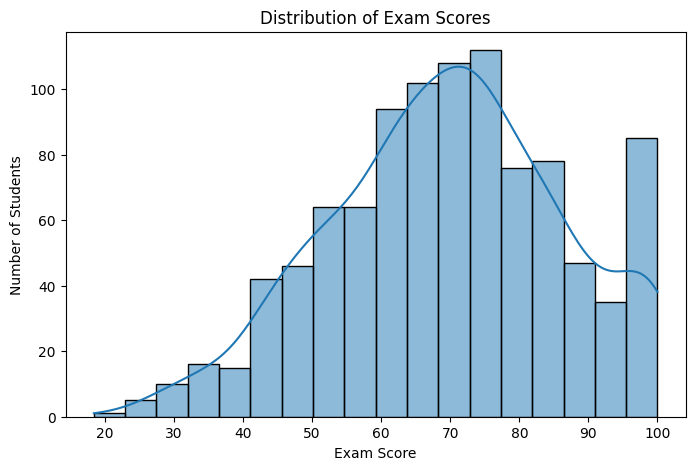

In [5]:
# Distribution of the target variable
plt.figure(figsize=(8,5))
sns.histplot(df["exam_score"], kde=True)
plt.title("Distribution of Exam Scores")
plt.xlabel("Exam Score")
plt.ylabel("Number of Students")
plt.show()

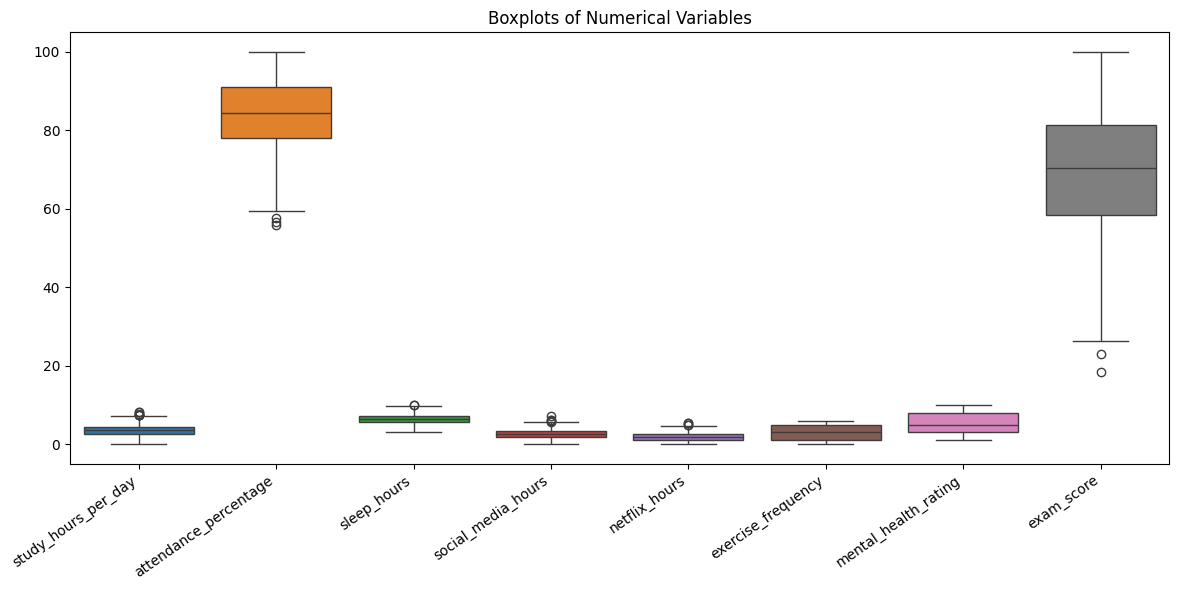

In [6]:
# Boxplots for important numerical variables
eda_numeric = [
    "study_hours_per_day",
    "attendance_percentage",
    "sleep_hours",
    "social_media_hours",
    "netflix_hours",
    "exercise_frequency",
    "mental_health_rating",
    "exam_score"
]

plt.figure(figsize=(12,6))
sns.boxplot(data=df[eda_numeric])
plt.xticks(rotation=35, ha="right")
plt.title("Boxplots of Numerical Variables")
plt.tight_layout()
plt.show()

In [7]:
# Correlation with exam score
corr_with_target = (
    df[numeric_cols]
    .corr(numeric_only=True)["exam_score"]
    .sort_values(ascending=False)
)

print("Correlation with exam_score:")
display(corr_with_target.to_frame("Correlation").round(3))

Correlation with exam_score:


,Correlation
exam_score,1.000
study_hours_per_day,0.825
mental_health_rating,0.322
exercise_frequency,0.160
sleep_hours,0.122
attendance_percentage,0.090
age,-0.009
social_media_hours,-0.167
netflix_hours,-0.172


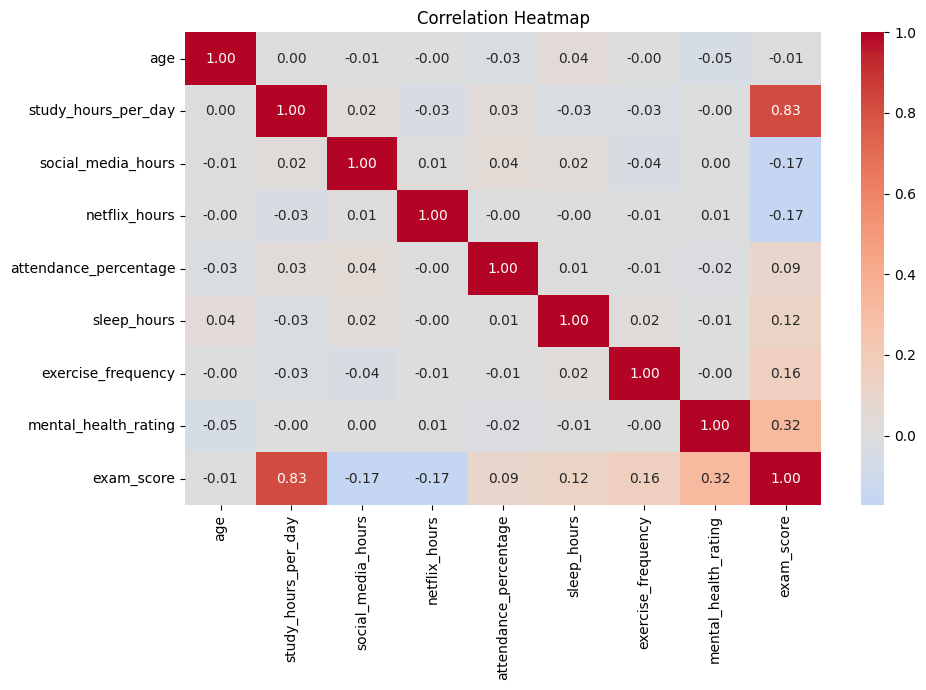

In [8]:
plt.figure(figsize=(10,7))
sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

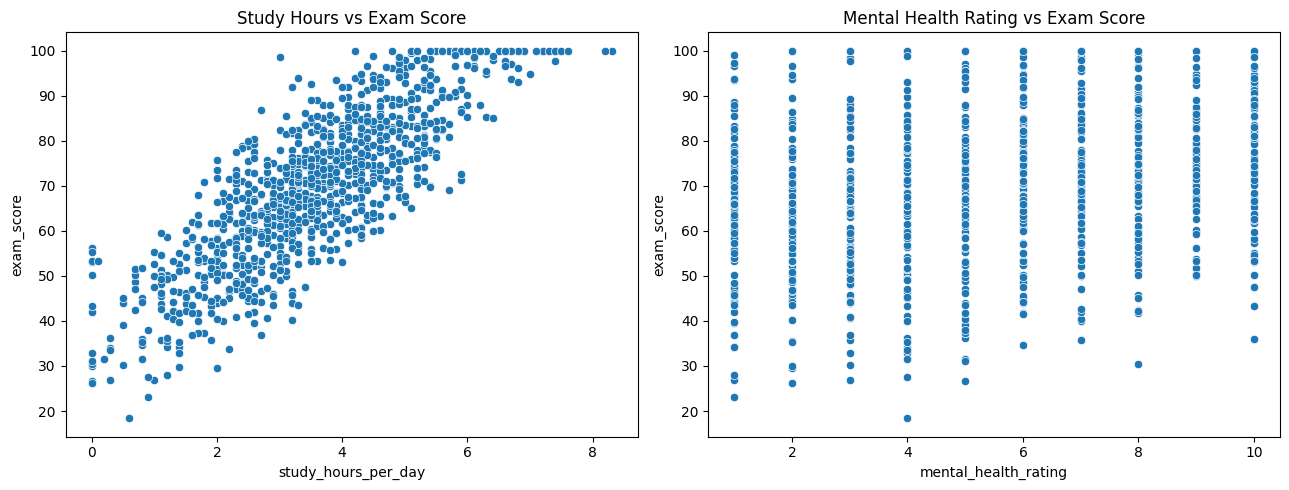

In [9]:
# Scatterplots for the strongest numerical relationships
fig, axes = plt.subplots(1, 2, figsize=(13,5))

sns.scatterplot(
    data=df, x="study_hours_per_day", y="exam_score", ax=axes[0]
)
axes[0].set_title("Study Hours vs Exam Score")

sns.scatterplot(
    data=df, x="mental_health_rating", y="exam_score", ax=axes[1]
)
axes[1].set_title("Mental Health Rating vs Exam Score")

plt.tight_layout()
plt.show()

In [10]:
# Group-wise analysis for categorical factors
categorical_for_analysis = [
    "gender",
    "part_time_job",
    "diet_quality",
    "parental_education_level",
    "internet_quality",
    "extracurricular_participation"
]

for col in categorical_for_analysis:
    print(f"\nAverage exam score by {col}:")
    display(
        df.groupby(col, dropna=False)["exam_score"]
        .agg(["count", "mean", "median"])
        .sort_values("mean", ascending=False)
        .round(2)
    )


Average exam score by gender:


,count,mean,median
gender,,,
Other,42,70.65,69.0
Female,481,69.74,70.7
Male,477,69.37,70.2



Average exam score by part_time_job:


,count,mean,median
part_time_job,,,
No,785,69.84,70.6
Yes,215,68.74,69.2



Average exam score by diet_quality:


...

,count,mean,median
parental_education_level,,,
Bachelor,350,70.27,71.70
NaN,91,70.03,71.00
High School,392,69.55,69.95
Master,167,68.09,66.80



Average exam score by internet_quality:


,count,mean,median
internet_quality,,,
Average,391,70.64,71.0
Poor,162,69.72,71.4
Good,447,68.65,69.3



Average exam score by extracurricular_participation:


,count,mean,median
extracurricular_participation,,,
Yes,318,69.62,70.65
No,682,69.59,70.35


### EDA interpretation

The strongest numerical relationship with `exam_score` is expected to come from `study_hours_per_day`. In this dataset, the correlation is approximately **0.83**, indicating a strong positive linear association.

`mental_health_rating` also shows a positive relationship (approximately **0.32**), while `social_media_hours` and `netflix_hours` show moderate negative relationships (approximately **−0.17** each).

These are statistical associations, not proof of causation.

# 3. Outlier Analysis

Potential outliers are investigated using the IQR rule:

\[
Lower\ Bound = Q_1 - 1.5(IQR)
\]

\[
Upper\ Bound = Q_3 + 1.5(IQR)
\]

Observations outside these bounds are flagged as potential outliers.

We will **identify and report** them rather than automatically deleting them, because an extreme study time, screen time, or exam score can be a legitimate student observation.

In [11]:
outlier_columns = [
    "study_hours_per_day",
    "social_media_hours",
    "netflix_hours",
    "attendance_percentage",
    "sleep_hours",
    "exercise_frequency",
    "mental_health_rating",
    "exam_score"
]

outlier_results = []

for col in outlier_columns:
    s = df[col].dropna()
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    mask = (df[col] < lower) | (df[col] > upper)

    outlier_results.append({
        "Variable": col,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Lower Bound": lower,
        "Upper Bound": upper,
        "Outlier Count": int(mask.sum())
    })

outlier_df = pd.DataFrame(outlier_results)
display(outlier_df.round(3))

,Variable,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count
0,study_hours_per_day,2.600,4.500,1.900,-0.250,7.350,7
1,social_media_hours,1.700,3.300,1.600,-0.700,5.700,5
2,netflix_hours,1.000,2.525,1.525,-1.287,4.812,4
3,attendance_percentage,78.000,91.025,13.025,58.462,110.563,3
4,sleep_hours,5.600,7.300,1.700,3.050,9.850,2
5,exercise_frequency,1.000,5.000,4.000,-5.000,11.000,0
6,mental_health_rating,3.000,8.000,5.000,-4.500,15.500,0
7,exam_score,58.475,81.325,22.850,24.200,115.600,2


# 4. Prepare Data for Machine Learning

### Regression target

`exam_score` is the continuous target.

### Features

The model uses all suitable predictor variables except:
- `student_id` — identifier, not a useful predictive feature
- `exam_score` — target variable

The selected predictors include study hours, attendance, sleep, social media, Netflix, exercise frequency, mental health, and other available demographic/lifestyle variables.

In [12]:
target = "exam_score"

X = df.drop(columns=["student_id", target]).copy()
y_reg = df[target].copy()

print("Feature shape:", X.shape)
print("Target shape:", y_reg.shape)
print("\nFeatures used:")
print(X.columns.tolist())

Feature shape: (1000, 14)
Target shape: (1000,)

Features used:
['age', 'gender', 'study_hours_per_day', 'social_media_hours', 'netflix_hours', 'part_time_job', 'attendance_percentage', 'sleep_hours', 'diet_quality', 'exercise_frequency', 'parental_education_level', 'internet_quality', 'mental_health_rating', 'extracurricular_participation']


### Preprocessing strategy

- Numerical missing values → median imputation
- Categorical missing values → most-frequent imputation
- Categorical variables → one-hot encoding
- Numerical variables → standardization

All preprocessing is placed inside a scikit-learn pipeline so that the transformations are learned from the training data only.

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(include="object").columns.tolist()

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

print("Numerical features:", numeric_features)
print("Categorical features:", categorical_features)

Numerical features: ['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours', 'attendance_percentage', 'sleep_hours', 'exercise_frequency', 'mental_health_rating']
Categorical features: ['gender', 'part_time_job', 'diet_quality', 'parental_education_level', 'internet_quality', 'extracurricular_participation']


# 5. Train/Test Split

We use an **80% training / 20% testing split** with `random_state=42` for reproducibility.

The class notes explain that the dataset is divided into training and test data so the model can be trained on one portion and evaluated on unseen data. fileciteturn3file0L13-L19

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_reg,
    test_size=0.20,
    random_state=42
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

Training rows: 800
Testing rows: 200


# 6. Regression — Linear Regression

We use **Multiple Linear Regression** because `exam_score` is a continuous numerical target and we have multiple predictor variables.

The class notes show the multiple-linear-regression form as a combination of multiple input features and describe the straight-line prediction relationship. fileciteturn3file0L5-L10

In [15]:
from sklearn.linear_model import LinearRegression

linear_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

linear_model.fit(X_train, y_train)

train_pred = linear_model.predict(X_train)
test_pred = linear_model.predict(X_test)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


## Regression Evaluation

### MAE

\[
MAE = \frac{1}{n}\sum |y_i-\hat{y}_i|
\]

### MSE

\[
MSE = \frac{1}{n}\sum (y_i-\hat{y}_i)^2
\]

### RMSE

\[
RMSE = \sqrt{MSE}
\]

### R²

\[
R^2 = 1-\frac{SS_{res}}{SS_{tot}}
\]

The class notes define MAE, MSE, RMSE, and R² on pages 9–10. fileciteturn3file0L27-L31

In [16]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def regression_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "MSE": mse,
        "RMSE": np.sqrt(mse),
        "R²": r2_score(y_true, y_pred)
    }

regression_results = pd.DataFrame({
    "Training": regression_metrics(y_train, train_pred),
    "Testing": regression_metrics(y_test, test_pred)
}).T

display(regression_results.round(4))

,MAE,MSE,RMSE,R²
Training,4.2142,28.5661,5.3447,0.9021
Testing,4.1923,26.5325,5.1510,0.8965


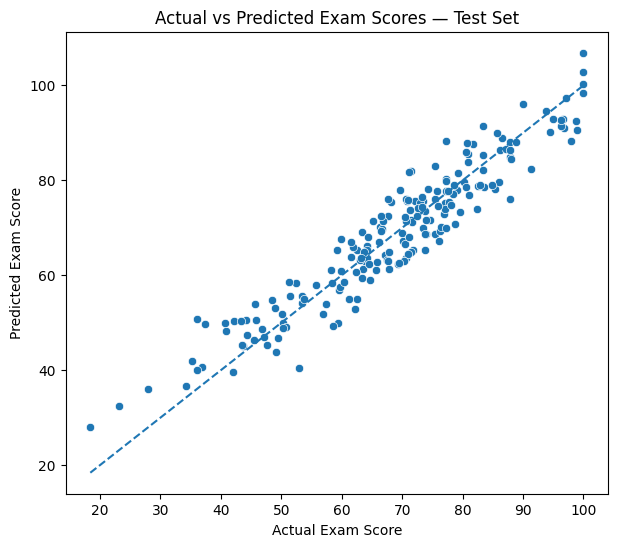

In [17]:
plt.figure(figsize=(7,6))
sns.scatterplot(x=y_test, y=test_pred)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)
plt.xlabel("Actual Exam Score")
plt.ylabel("Predicted Exam Score")
plt.title("Actual vs Predicted Exam Scores — Test Set")
plt.show()

### Regression interpretation

The model's R² value indicates how much of the variation in exam scores is explained by the selected predictors. MAE and RMSE express prediction error in exam-score units, so lower values indicate smaller prediction errors.

The training and testing metrics should be compared before making a final judgment about model fit.

# 7. Classification — Pass / Fail

We convert the continuous exam score into a binary target:

\[
Pass =
\begin{cases}
1, & exam\_score \ge 50\\
0, & exam\_score < 50
\end{cases}
\]

The classification model will use the **same prepared feature set**.

In [18]:
y_class = (df["exam_score"] >= 50).astype(int)

print("Pass count:", (y_class == 1).sum())
print("Fail count:", (y_class == 0).sum())
print("Pass rate:", round(y_class.mean() * 100, 2), "%")

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X, y_class,
    test_size=0.20,
    random_state=42,
    stratify=y_class
)

Pass count: 869
Fail count: 131
Pass rate: 86.9 %


# 8. Logistic Regression

Logistic Regression is appropriate for a binary Pass/Fail target.

The class notes introduce logistic regression for classification and describe the sigmoid activation that maps predictions to values between 0 and 1. fileciteturn3file0L19-L25

In [19]:
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=2000))
])

logistic_model.fit(X_train_c, y_train_c)

train_class_pred = logistic_model.predict(X_train_c)
test_class_pred = logistic_model.predict(X_test_c)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


## Classification Evaluation

### Confusion Matrix

The four outcomes are:
- True Positive (TP)
- True Negative (TN)
- False Positive (FP)
- False Negative (FN)

### Accuracy

\[
Accuracy=\frac{TP+TN}{TP+TN+FP+FN}
\]

### Precision

\[
Precision=\frac{TP}{TP+FP}
\]

### Recall

\[
Recall=\frac{TP}{TP+FN}
\]

### F1-score

\[
F1=2\times\frac{Precision\times Recall}{Precision+Recall}
\]

These definitions are covered in the class notes on pages 11–12. fileciteturn3file0L33-L37

In [20]:
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

def classification_metrics(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1-Score": f1_score(y_true, y_pred, zero_division=0)
    }

classification_results = pd.DataFrame({
    "Training": classification_metrics(y_train_c, train_class_pred),
    "Testing": classification_metrics(y_test_c, test_class_pred)
}).T

display(classification_results.round(4))

,Accuracy,Precision,Recall,F1-Score
Training,0.9575,0.9701,0.9813,0.9757
Testing,0.9550,0.9714,0.9770,0.9742


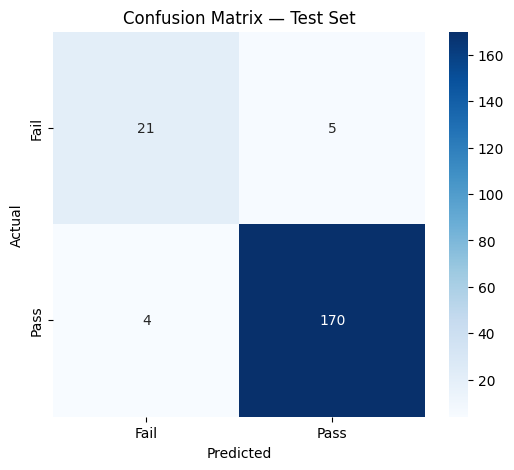

Confusion Matrix:
[[ 21   5]
 [  4 170]]


In [21]:
cm = confusion_matrix(y_test_c, test_class_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Fail", "Pass"],
    yticklabels=["Fail", "Pass"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Test Set")
plt.show()

print("Confusion Matrix:")
print(cm)

# 9. Training vs Testing Performance

### Overfitting

Overfitting occurs when a model performs very well on training data but substantially worse on unseen test data.

### Underfitting

Underfitting occurs when a model performs poorly on both training and test data.

The class notes describe overfitting as strong training performance with weaker test performance and underfitting as poor performance due to a model that is too simple. fileciteturn3file0L13-L19

In [22]:
print("REGRESSION")
print("-" * 50)
display(regression_results.round(4))

reg_r2_gap = regression_results.loc["Training", "R²"] - regression_results.loc["Testing", "R²"]
print(f"Regression R² train-test gap: {reg_r2_gap:.4f}")

print("\nCLASSIFICATION")
print("-" * 50)
display(classification_results.round(4))

class_acc_gap = (
    classification_results.loc["Training", "Accuracy"]
    - classification_results.loc["Testing", "Accuracy"]
)
print(f"Classification accuracy train-test gap: {class_acc_gap:.4f}")

REGRESSION
--------------------------------------------------


,MAE,MSE,RMSE,R²
Training,4.2142,28.5661,5.3447,0.9021
Testing,4.1923,26.5325,5.1510,0.8965


Regression R² train-test gap: 0.0056

CLASSIFICATION
--------------------------------------------------


,Accuracy,Precision,Recall,F1-Score
Training,0.9575,0.9701,0.9813,0.9757
Testing,0.9550,0.9714,0.9770,0.9742


Classification accuracy train-test gap: 0.0025


### Model-fit conclusion

For this dataset, the regression model has very similar training and testing performance, with R² around **0.90** on both sets. The classification model also has very similar training and testing metrics, around **96% accuracy** on the test set.

Therefore, there is **no strong evidence of overfitting or underfitting** in these results. The small train-test differences suggest that the models generalize reasonably well to the held-out test data.

# 10. Most Important Findings

### EDA findings
- `study_hours_per_day` has the strongest positive numerical association with `exam_score` (approximately **r = 0.83**).
- `mental_health_rating` has a moderate positive association with exam score (approximately **r = 0.32**).
- `social_media_hours` and `netflix_hours` have moderate negative associations with exam score (approximately **−0.17** each).
- Several numerical variables contain potential IQR outliers, but they were investigated rather than automatically removed.

### Model findings
- Multiple Linear Regression predicts the continuous exam score with strong explanatory power.
- Logistic Regression performs strongly for the 50-mark Pass/Fail classification task.
- Similar training and testing performance suggests good generalization without a major overfitting signal.

# 11. Five Meaningful Statistical / ML Insights

1. **Study time is the strongest observed predictor of exam performance.** Its correlation with exam score is approximately 0.83, and the regression model confirms that lifestyle/study features can explain a large portion of score variation.

2. **Mental wellbeing is also related to academic performance.** Mental health rating has a positive correlation with exam score, although this association is much weaker than study hours.

3. **Higher entertainment/social-media exposure is associated with lower exam scores.** Social media and Netflix hours both show negative correlations with exam score. These relationships should be interpreted as associations rather than causal effects.

4. **The Pass/Fail classification problem is highly predictable in this dataset.** With a 50-mark threshold, the logistic regression model achieves approximately 96% test accuracy, with high precision, recall, and F1-score.

5. **The models show reasonable generalization.** Training and testing performance are close for both regression and classification, so there is no strong evidence of overfitting or underfitting based on the selected evaluation metrics.

# 12. Final Conclusion

This project followed a complete machine-learning workflow from EDA through preprocessing, model training, prediction, and evaluation.

The analysis identified study hours as the strongest numerical factor associated with exam score, while mental health, screen/social-media use, sleep, attendance, exercise, and other student characteristics provide additional information.

A Multiple Linear Regression model was used to predict the continuous `exam_score`, and a Logistic Regression model was used to classify students as Pass or Fail using **50 marks** as the threshold. Both models were evaluated on unseen test data using the metrics covered in class.

The close relationship between training and testing performance indicates that the models generalize reasonably well for this dataset. However, these models identify statistical patterns and predictive relationships; they should not be interpreted as proof that changing one student habit will necessarily cause a particular change in exam performance.

# 13. Final Submission Checklist

| Requirement | Status |
|---|---|
| Dataset inspection | ✅ |
| Numerical and categorical variables identified | ✅ |
| Distributions examined | ✅ |
| Relationships and correlations examined | ✅ |
| Missing values examined | ✅ |
| Potential outliers examined | ✅ |
| Factors related to exam_score identified | ✅ |
| Features selected | ✅ |
| Preprocessing performed | ✅ |
| Train/test split | ✅ |
| Linear Regression | ✅ |
| Regression predictions | ✅ |
| MAE | ✅ |
| MSE | ✅ |
| RMSE | ✅ |
| R² | ✅ |
| Pass/Fail target using 50 marks | ✅ |
| Logistic Regression classification | ✅ |
| Confusion matrix | ✅ |
| Accuracy | ✅ |
| Precision | ✅ |
| Recall | ✅ |
| F1-score | ✅ |
| Training vs testing comparison | ✅ |
| Overfitting / underfitting discussion | ✅ |
| 5 meaningful insights | ✅ |
| Final conclusion | ✅ |